In [10]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df = pd.read_csv('train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(37057, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [11]:
print(mercari_df.info)

<bound method DataFrame.info of        train_id                                   name  item_condition_id  \
0             0    MLB Cincinnati Reds T Shirt Size XL                  3   
1             1       Razer BlackWidow Chroma Keyboard                  3   
2             2                         AVA-VIV Blouse                  1   
3             3                  Leather Horse Statues                  1   
4             4                   24K GOLD plated rose                  1   
...         ...                                    ...                ...   
37052     37052  Victoria Secret Pink X Small Tank Top                  1   
37053     37053                               Reserved                  3   
37054     37054       Medela's hand's free pumping bra                  1   
37055     37055                  Rae Dunn Hop Canister                  1   
37056     37056                         Makeup bundle!                  3   

                                           

/tmp/ipython-input-3032566537.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train_df, bins=100)


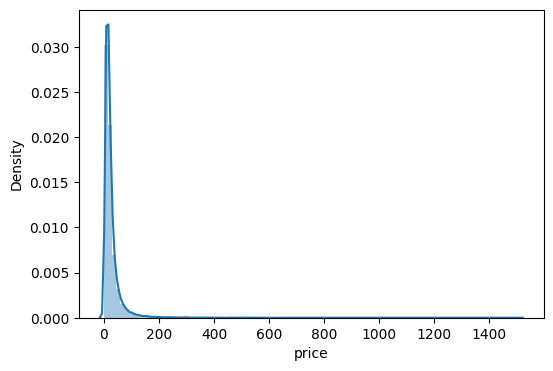

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.distplot(y_train_df, bins=100)
plt.show()

/tmp/ipython-input-2740943254.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train_df, bins=50)


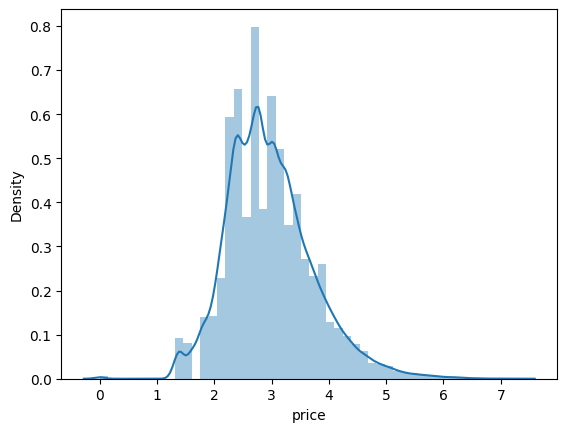

In [13]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.distplot(y_train_df, bins=50)
plt.show()

In [14]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [15]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    20446
1    16611
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    16088
3    10762
2     9311
4      822
5       74
Name: count, dtype: int64


In [16]:
boolean_cond = mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(2066)

In [17]:
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return['Other_Null', 'Other_Null', 'Other_Null']

mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
  zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))

print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수 :\n', mercari_df['cat_jung'].nunique())
print('소분류 개수 :\n', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     16541
Beauty                     5323
Kids                       4248
Electronics                3143
Men                        2232
Home                       1677
Vintage & Collectibles     1185
Other                      1137
Handmade                    771
Sports & Outdoors           620
Other_Null                  180
Name: count, dtype: int64
중분류 개수 :
 110
소분류 개수 :
 623


In [18]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna('Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna('Other_Null')

mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


In [19]:
print('brand name의 유형 건수: ', mercari_df['brand_name'].nunique())
print('brand name sample 5건: \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수:  1356
brand name sample 5건: 
 brand_name
Other_Null           15965
PINK                  1359
Nike                  1326
Victoria's Secret     1147
LuLaRoe                778
Name: count, dtype: int64


In [20]:
print('name의 종류 개수:', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수: 35729
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


In [21]:
pd.set_option('max_colwidth', 200)

print('item_description 평균 문자열 크기: ',mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기:  145.83482203092532


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df['name'])


tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])
print('name vectorization shape: ', X_name.shape)
print('item_description vectorization shape: ', X_descp.shape)

name vectorization shape:  (37057, 15420)
item_description vectorization shape:  (37057, 50000)


In [23]:
from sklearn.preprocessing import LabelBinarizer

mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Unknown')
mercari_df['item_condition_id'] = mercari_df['item_condition_id'].fillna(0)
mercari_df['shipping'] = mercari_df['shipping'].fillna(0)
mercari_df['cat_dae'] = mercari_df['cat_dae'].fillna('Unknown')
mercari_df['cat_jung'] = mercari_df['cat_jung'].fillna('Unknown')
mercari_df['cat_so'] = mercari_df['cat_so'].fillna('Unknown')

lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [24]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(37057, 1356), X_item_cond_id shape:(37057, 5)
X_shipping shape:(37057, 1), X_cat_dae shape:(37057, 11)
X_cat_jung shape:(37057, 110), X_cat_so shape:(37057, 623)


In [25]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

X_features_sparse = hstack(sparse_matrix_list).tocsr()
print('Shape of X_features_sparse: ', X_features_sparse.shape)

del X_features_sparse
gc.collect()

Shape of X_features_sparse:  (37057, 66170)


8601

In [26]:
def rmsle(y, y_pred):
    return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):

  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)

  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

In [27]:
def evaluate_org_price(y_test, preds):
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)

  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

In [28]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
  X = hstack(matrix_list).tocsr()
  X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'], test_size=0.2, random_state=156)

  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X, X_train, X_test, y_train
  gc.collect()

  return preds, y_test

In [29]:
# ===== 0) 결측치/이상치 정리 (벡터 만들기 전에 반드시 실행) =====
import numpy as np

# 텍스트는 빈 문자열로 (vectorizer가 NaN 못 받음)
mercari_df['name'] = mercari_df['name'].fillna('')
mercari_df['item_description'] = mercari_df['item_description'].fillna('')

# 범주형은 Unknown
for col in ['brand_name', 'cat_dae', 'cat_jung', 'cat_so']:
    mercari_df[col] = mercari_df[col].fillna('Unknown').astype(str)

# 숫자/이진은 0으로
mercari_df['item_condition_id'] = mercari_df['item_condition_id'].fillna(0).astype(int)
mercari_df['shipping'] = mercari_df['shipping'].fillna(0).astype(int)

# price는 NaN 제거 + 0 이하 제거 (RMSLE 안전)
mercari_df = mercari_df.dropna(subset=['price'])
mercari_df = mercari_df[mercari_df['price'] > 0].copy()

# ===== 1) X_name / X_descp 다시 생성 (예시: TF-IDF) =====
from sklearn.feature_extraction.text import TfidfVectorizer

tfv_name = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_name = tfv_name.fit_transform(mercari_df['name'])

tfv_desc = TfidfVectorizer(max_features=100000, ngram_range=(1,2))
X_descp = tfv_desc.fit_transform(mercari_df['item_description'])

# ===== 2) LabelBinarizer들 다시 생성 =====
from sklearn.preprocessing import LabelBinarizer

lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

from sklearn.linear_model import Ridge

linear_model = Ridge(solver="lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함했을 때 rmsle 값: ', evaluate_org_price(y_test, linear_preds))


Item Description을 제외했을 때 rmsle 값:  0.5303674838116248
Item Description을 포함했을 때 rmsle 값:  0.5406604955822123


In [30]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함했을 때 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값:  0.5303674838116248
Item Description을 포함했을 때 rmsle 값:  0.5406604955822123


In [31]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=200,      # 🔻 대폭 감소
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1             # 🔥 멀티코어
)

sparse_matrix_list = (X_descp, X_brand, X_item_cond_id, X_shipping,
                      X_cat_dae, X_cat_jung, X_cat_so)

lgbm_preds, y_test = model_train_predict(model=lgbm_model,
                                         matrix_list=sparse_matrix_list)

preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:',
      evaluate_org_price(y_test, preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.988849 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 203282
[LightGBM] [Info] Number of data points in the train set: 29623, number of used features: 6963
[LightGBM] [Info] Start training from score 2.975194


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.5304033761635844
